# Fairness : Projet

*Travail réalisé par Cyprien BRION, Rayane ZENAIDI, Christian ESSOME NDOUMIN - Fairness, groupe 2*

## Introduction

L’utilisation croissante des méthodes d’apprentissage automatique dans le domaine médical soulève des enjeux majeurs en matière d’équité, en particulier lorsque les décisions d’un modèle peuvent varier selon certaines caractéristiques des patients. Dans le cas de l’imagerie médicale, ces questions sont d’autant plus importantes que les modèles de vision par ordinateur peuvent apprendre non seulement des indices liés à la pathologie recherchée, mais aussi des informations corrélées à des attributs sensibles tels que l’âge, le genre ou encore certaines conditions d’acquisition. Un modèle peut ainsi reproduire, voire accentuer, des biais déjà présents dans les données.

Dans ce projet, nous nous intéressons au jeu de données NIH Chest X-ray, composé d’images de radiographies thoraciques associées à différentes métadonnées patient. Contrairement au mi-projet, qui portait sur l’analyse des métadonnées, nous étudierons ici un classifieur d’images basé sur un modèle ResNet18. Ce dernier, prend uniquement les images en entrée pour prédire si un patient est malade ou sain, tandis que les métadonnées sont utilisées en parallèle pour analyser les déséquilibres du jeu de données, mesurer d’éventuels biais, puis appliquer différentes stratégies de mitigation comme nous l'avons fait dans le mi-projet.

L’objectif de ce notebook est donc double. Dans un premier temps, nous reprenons de façon plus synthétique les principales étapes du mi-projet : préparation de la donnée, vérification de sa qualité, étude rapide des déséquilibres et mise en évidence de biais potentiels selon certains groupes. Dans un second temps, nous nous concentrons sur le cœur du projet en entraînant le classifieur d’images fourni, puis en étudiant l’impact de différentes méthodes de pré-processing et de post-processing sur les performances du modèle. Nous comparerons ces approches à la fois du point de vue de la balanced accuracy et de plusieurs métriques de fairness, afin d’évaluer dans quelle mesure il est possible de réduire les biais sans dégrader excessivement la qualité des prédictions.

## I. Préparation de la donnée

### a. Chargement de données et aperçu des données

Commençons par charger notre jeu de données :

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from aif360.sklearn.preprocessing import Reweighing
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import DisparateImpactRemover
from aif360.sklearn.metrics import *
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import  balanced_accuracy_score

In [3]:
# Pour le chargement du jeu de données
df = pd.read_csv("DATA/metadata.csv")
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000013_000.png,No Finding,0,13,61,M,PA,2021,2021,0.194311,0.194311,NaN,valid,sain,1
1,00000013_001.png,Emphysema|Pneumothorax,1,13,60,M,AP,3056,2544,0.139000,0.139000,NaN,valid,malade,1
2,00000013_002.png,Emphysema|Pneumothorax,2,13,60,M,AP,3056,2544,0.139000,0.139000,NaN,valid,malade,1
3,00000013_003.png,Pleural_Thickening,3,13,60,M,AP,2996,2544,0.139000,0.139000,NaN,valid,malade,1
4,00000013_004.png,Effusion|Emphysema|Infiltration|Pneumothorax,4,13,60,M,AP,3056,2544,0.139000,0.139000,NaN,valid,malade,1


Ensuite, observons plus en détail les caractéristiques de ce jeu de données :

In [4]:
df.shape

(5481, 15)

Analysons désormais le type des variables contenues dans ce dataset :

In [5]:
df.dtypes

Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
Unnamed: 11                    float64
train_valid                     object
label                           object
WEIGHTS                          int64
dtype: object

### b. Vérifications et nettoyage du jeu de données

Vérifions désormais la présence de valeurs manquantes dans le jeu de données.

In [6]:
df.isna().sum()

Image Index                       0
Finding Labels                    0
Follow-up #                       0
Patient ID                        0
Patient Age                       0
Patient Gender                    0
View Position                     0
OriginalImage[Width               0
Height]                           0
OriginalImagePixelSpacing[x       0
y]                                0
Unnamed: 11                    5481
train_valid                       0
label                             0
WEIGHTS                           0
dtype: int64

On remarque qu'il y a 5481 colonnes manquantes pour la colonne `Unnamed: 11`. Ceci est probablement lié à un léger décalage lors de l'export.
On va donc nettoyer le dataset, en supprimant les colonnes qui sont entièrement vides :

In [7]:
# On supprime les colonnes entièrement vides
empty_cols = df.columns[df.isna().all()]
print("Colonnes entièrement vides :", list(empty_cols))

df = df.drop(columns=empty_cols)

Colonnes entièrement vides : ['Unnamed: 11']


On vérifie que le DataFrame ne contient plus de valeurs nulles :

In [8]:
df.isna().sum()

Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImage[Width            0
Height]                        0
OriginalImagePixelSpacing[x    0
y]                             0
train_valid                    0
label                          0
WEIGHTS                        0
dtype: int64

Regardons désormais si notre jeu de données contient des valeurs aberrantes. Bien sûr, cela ne concerne que les variables numériques.

In [9]:
df.describe()

,Follow-up #,Patient ID,Patient Age,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],WEIGHTS
count,5481.000000,5481.000000,5481.000000,5481.000000,5481.000000,5481.000000,5481.000000,5481.0
mean,9.157088,13957.939245,46.741835,2651.378033,2499.520343,0.155429,0.155429,1.0
std,18.103190,8319.503802,16.887118,345.964529,400.131680,0.016349,0.016349,0.0
min,0.000000,13.000000,1.000000,1567.000000,1365.000000,0.115000,0.115000,1.0
25%,0.000000,6700.000000,35.000000,2500.000000,2048.000000,0.143000,0.143000,1.0
50%,3.000000,13992.000000,48.000000,2544.000000,2544.000000,0.143000,0.143000,1.0
75%,9.000000,20307.000000,60.000000,2992.000000,2991.000000,0.168000,0.168000,1.0
max,157.000000,30792.000000,153.000000,3056.000000,3056.000000,0.198800,0.198800,1.0


On remarque ici qu'il y a des valeurs probablement aberrantes pour la colonne `Patient Age`. En effet, le maximum pour cette colonne est de 153, ce qui signifierait qu'un patient à 153 ans, ce qui n'est clairement pas réaliste.
En revanche, les valeurs pour les autres colonnes semblent être cohérentes.

Pour corriger ce problème, nous allons filtrer les valeurs de la colonne `Patient Age` selon un intervalle réaliste : 

In [10]:
df = df[(df["Patient Age"] >= 0) & (df["Patient Age"] <= 120)]
df["Patient Age"].describe()

count    5480.000000
mean       46.722445
std        16.827528
min         1.000000
25%        35.000000
50%        48.000000
75%        60.000000
max        87.000000
Name: Patient Age, dtype: float64

Après nettoyage, les valeurs sont désormais bien plus réalistes.

Effectuons une analyse pour observer le nombre de valeurs distinctes par variable afin de confirmer qu'il n'y aurait pas de valeurs manquantes encodées de manière implicite.

In [11]:
df.nunique()

Image Index                    5480
Finding Labels                  247
Follow-up #                     158
Patient ID                     1500
Patient Age                      85
Patient Gender                    2
View Position                     2
OriginalImage[Width             332
Height]                         322
OriginalImagePixelSpacing[x      11
y]                               11
train_valid                       2
label                             2
WEIGHTS                           1
dtype: int64

On remarque donc que le nombre de valeurs distinctes est cohérent avec l'énoncé. Aucune variable ne présente donc de valeurs manquantes qui auraient pu être encodées implicitement.
Néanmoins, à partir de ces résultats on peut noter que :
* Les variables `Patient Gender` et `View Position` ne possèdent que deux valeurs distinctes chacune, ce qui en fait des variables clés pour l'analyse des biais.

Pour finir, vérifions si des lignes ont été dupliquées :

In [12]:
dup_rows = df.duplicated().sum()
print(f"Doublons exacts (toutes colonnes) : {dup_rows}")

Doublons exacts (toutes colonnes) : 0


Il n'y a donc aucun doublon dans notre dataset.

Pour faciliter l'analyse, nous allons transformer la variable continue `Patient Age` en catégories interprétables. Pour cela, nous allons utiliser des tranches d'âge.

In [13]:
df["age_group"] = pd.cut(
    df["Patient Age"],
    # Remarque : on commence à 1 car l'âge minimal est 1 dans le dataset.
    bins=[1, 18, 30, 45, 60, 75, 120],
    include_lowest=True
)
df["age_group"].value_counts().sort_index()

age_group
(0.999, 18.0]     246
(18.0, 30.0]      853
(30.0, 45.0]     1423
(45.0, 60.0]     1715
(60.0, 75.0]     1101
(75.0, 120.0]     142
Name: count, dtype: int64

De même, afin de pouvoir utiliser les métriques de fairness, nous allons effectuer un encodage binaire (`gender_bin`) pour le genre :

In [14]:
df["gender_bin"] = (df["Patient Gender"] == "M").astype(int)


**Remarque :** on a fixé ici arbitrairement la convention suivante pour les valeurs de `gender_bin` : 1 correspond aux individus de sexe masculin et 0 les individus de sexe féminin.

On effectue le même traitement pour l'attribut `View Position` toujours en vue de l'utilisation des métriques de fairness. On nommera `view_bin` la colonne contenant cet encodage.

In [15]:
df["view_bin"] = (df["View Position"] == "PA").astype(int)

**Remarque :** on a fixé ici arbitrairement la convention suivante pour les valeurs de `view_bin` : 1 pour PA et 0 pour AP.

On termine par encoder l'attribut binaire `label` afin qu'il soit interprétable. On nommera `label_bin`, la colonne contenant cet encodage.

On commence par vérifier que `label` ne prends bien que deux valeurs possibles :

In [16]:
print(df["label"].unique())

['sain' 'malade']


On procède donc à l'encodage :

In [17]:
df["label_bin"] = df["label"].map({"sain": 0, "malade": 1})

**Remarque :** on a fixé ici arbitrairement la convention suivante pour les valeurs de `label_bin` : 1 pour malade et 0 pour sain.

## II. Analyse descriptive et observation des biais

**Remarque :** contrairement au mi-projet, nous serons plus bref pour cette partie en ne présentant que l'analyse des variables clés qui pourraient influencer l'apprentissage du modèle et présenter des biais.

### a. Analyse univariée

#### 1. Répartition de la variable cible `label`

Commençons par étudier la répartition de la variable cible `label` à l'aide d'un barplot, qui indique si le patient est sain ou malade. Cette première analyse permet de vérifier si les deux classes sont équilibrées dans le jeu de données, un point capital avant l’entraînement du classifieur.

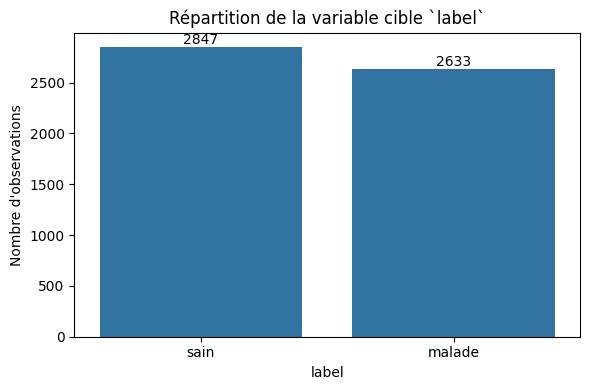

In [18]:
# On calcule le nombre d'occurrences de chaque classe de label
label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="label")

ax.set_title("Répartition de la variable cible `label`")
ax.set_xlabel("label")
ax.set_ylabel("Nombre d'observations")

# On ajoute le nombre exact d'observations au-dessus de chaque barre
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

On affiche les proportions pour compléter l'analyse :

In [19]:
print("Répartition en proportions :")
print(df["label"].value_counts(normalize=True).sort_index())

Répartition en proportions :
label
malade    0.480474
sain      0.519526
Name: proportion, dtype: float64


La variable cible `label` apparaît globalement équilibrée, même si la classe sain est légèrement plus représentée que la classe malade. Le jeu de données ne présente donc pas ici de déséquilibre marqué entre les deux classes.

#### 2. Répartition de la variable sensible `age_group`

Observons maintenant la répartition de l’âge des patients à travers la variable `age_group`, obtenue en découpant l’âge en plusieurs tranches. Cette représentation permet d’identifier d’éventuels déséquilibres de population entre les différentes classes d’âge présentes dans le jeu de données.

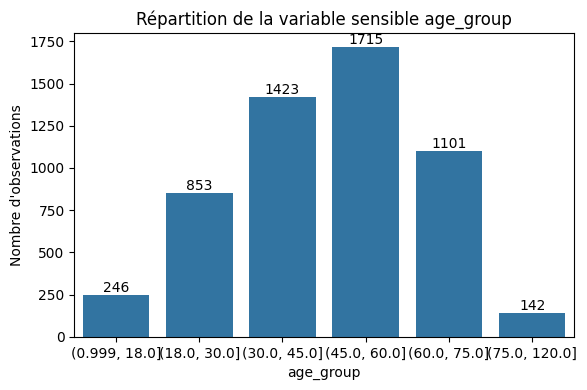

In [20]:
plt.figure(figsize=(6, 4))

# Barplot de la répartition de la variable age_group
ax = sns.countplot(data=df, x="age_group")

# Titre et noms des axes
ax.set_title("Répartition de la variable sensible age_group")
ax.set_xlabel("age_group")
ax.set_ylabel("Nombre d'observations")

# On ajoute le nombre exact d'observations au-dessus de chaque barre
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

# Ajustement automatique
plt.tight_layout()
plt.show()

On affiche les proportions pour compléter l'analyse :

In [21]:
print("Répartition en proportions :")
print(df["age_group"].value_counts(normalize=True).sort_index())

Répartition en proportions :
age_group
(0.999, 18.0]    0.044891
(18.0, 30.0]     0.155657
(30.0, 45.0]     0.259672
(45.0, 60.0]     0.312956
(60.0, 75.0]     0.200912
(75.0, 120.0]    0.025912
Name: proportion, dtype: float64


On observe que les patients sont majoritairement concentrés dans les classes d’âge intermédiaires, en particulier entre 30 et 60 ans, avec un pic pour la tranche 45–60 ans. À l’inverse, les patients les plus jeunes et les plus âgés sont nettement moins représentés. Le jeu de données présente donc un déséquilibre selon l’âge mais ceci est plutôt cohérent avec les tendances réelles.

#### 3. Répartition de la variable sensible `gender_bin`

Regardons maintenant la répartition de la variable `gender_bin` à l'aide d'un barplot, issue de la binarisation du genre des patients. Cette analyse permet de vérifier si les deux groupes sont représentés de manière équilibrée dans le jeu de données.

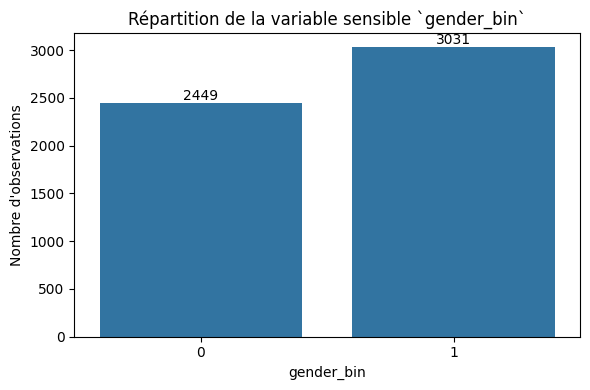

In [22]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="gender_bin")

ax.set_title("Répartition de la variable sensible `gender_bin`")
ax.set_xlabel("gender_bin")
ax.set_ylabel("Nombre d'observations")

# On ajoute le nombre exact d'observations au-dessus de chaque barre
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

On affiche les proportions :

In [23]:
print("Répartition en proportions :")
print(df["gender_bin"].value_counts(normalize=True).sort_index())

Répartition en proportions :
gender_bin
0    0.446898
1    0.553102
Name: proportion, dtype: float64


**Rappel :** on a fixé précedemment la convention suivante pour les valeurs de `gender_bin` : 1 correspond aux individus de sexe masculin et 0 les individus de sexe féminin.

On observe donc un léger déséquilibre dans la répartition de `gender_bin`, le groupe codé par la valeur 1 étant un peu plus représenté que celui codé par la valeur 0. Ce déséquilibre reste toutefois modéré, mais il devra être pris en compte dans l’analyse des biais du jeu de données.

#### 4. Répartition de la variable sensible `view_bin`

Analysons enfin la répartition de la variable `view_bin` à l'aide d'un barplot, issue de la binarisation de la position de prise de vue. Cette étape permet de vérifier si les deux modalités sont représentées de manière équilibrée dans le jeu de données.

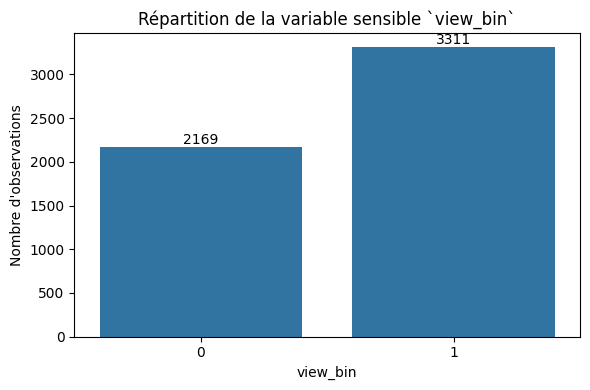

In [24]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="view_bin")

ax.set_title("Répartition de la variable sensible `view_bin`")
ax.set_xlabel("view_bin")
ax.set_ylabel("Nombre d'observations")

# On ajoute le nombre exact d'observations au-dessus de chaque barre
for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

On affiche les proportions associées :

In [25]:
print("Répartition en proportions :")
print(df["view_bin"].value_counts(normalize=True).sort_index())

Répartition en proportions :
view_bin
0    0.395803
1    0.604197
Name: proportion, dtype: float64


**Rappel :** on a fixé précedemment la convention suivante pour les valeurs de `view_bin` : 1 pour PA et 0 pour AP.

On observe un déséquilibre plus marqué pour la variable `view_bin`, les clichés en position PA (valeur 1) étant nettement plus représentés que les clichés en position AP (valeur 0). La position de prise de vue n’est donc pas uniformément répartie dans le jeu de données, ce qui pourra influencer les analyses de biais et, potentiellement, l’apprentissage du modèle.

### Synthèse de l'analyse univariée

L’analyse univariée nous a permis d’examiner la répartition des principales variables que l'on utilisera dans la suite du projet. La variable cible `label` apparaît globalement équilibrée, avec une légère majorité de patients sains. En revanche, les variables sensibles présentent des déséquilibres plus marqués. La distribution de `age_group` montre que les patients sont principalement concentrés dans les classes d’âge intermédiaires, tandis que les âges extrêmes sont peu représentés. La variable `gender_bin` reste relativement équilibrée, malgré une légère surreprésentation d’un des deux groupes. Enfin, le déséquilibre le plus net concerne `view_bin`, avec une majorité d’images prises en position PA par rapport à la position AP. Ces résultats mettent donc en évidence plusieurs déséquilibres de représentation dans le jeu de données, susceptibles d’avoir un impact sur l’apprentissage du classifieur et sur l’analyse des métriques de fairness.

### b. Analyse bivariée (biais / dépendances)

Après avoir étudié la répartition individuelle de chaque variable, nous allons maintenant croiser les variables sensibles (`gender_bin`, `view_bin`, `age_group`) avec la variable cible `label` ainsi qu'entre elles. L'objectif est de mettre en évidence d'éventuelles dépendances et biais présents dans les données, avant même l'entraînement du classifieur.

#### 1. Croisement `label` × `gender_bin`

Commençons par étudier la relation entre le genre du patient et le fait d'être malade ou sain. Nous affichons d'abord la table de contingence, puis un barplot empilé normalisé pour visualiser les proportions.

In [26]:
# Table de contingence label × gender_bin
ct_label_gender = pd.crosstab(df["label"], df["gender_bin"], margins=True)
ct_label_gender

gender_bin,0,1,All
label,,,
malade,1117,1516,2633
sain,1332,1515,2847
All,2449,3031,5480


In [27]:
# Proportions par genre (profils colonnes)
ct_label_gender_norm = pd.crosstab(df["label"], df["gender_bin"], normalize="columns")
ct_label_gender_norm

gender_bin,0,1
label,,
malade,0.456105,0.500165
sain,0.543895,0.499835


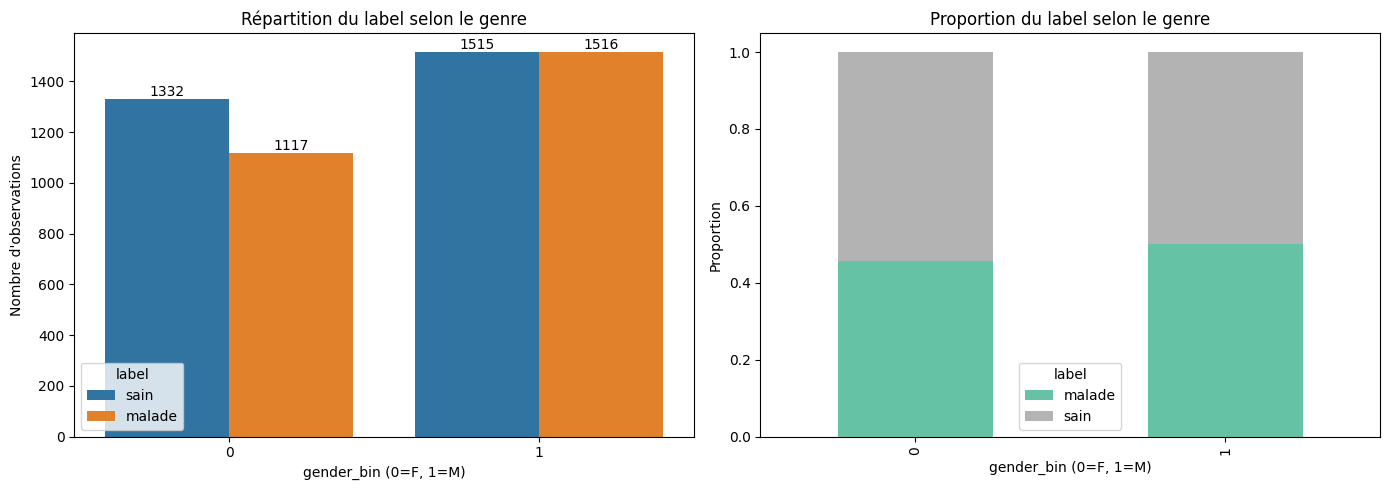

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot groupé : effectifs par label et genre
sns.countplot(data=df, x="gender_bin", hue="label", ax=axes[0])
axes[0].set_title("Répartition du label selon le genre")
axes[0].set_xlabel("gender_bin (0=F, 1=M)")
axes[0].set_ylabel("Nombre d'observations")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d")

# Barplot empilé normalisé (profils colonnes)
ct_label_gender_norm.T.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Proportion du label selon le genre")
axes[1].set_xlabel("gender_bin (0=F, 1=M)")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="label")

plt.tight_layout()
plt.show()

On note des proportions de label selon le genre proches de 50%, avec des écarts de moins de 5%, il ne semble donc pas y avoir de biais vis-à-vis de la distribution des labels par rapport au genre. Bien que l'on note un écart non-négligeable entre le nombre d'osbservations de profils sains féminins, par rapport aux profils malades (8% de différence), ce qui pourrait amener à un sous-diagnostic de maladie chez les patientes

#### 2. Croisement `label` × `view_bin`

Étudions maintenant la relation entre la position de prise de vue et le diagnostic. La position AP est souvent associée à des patients alités ou en urgence, ce qui pourrait induire un biais dans la proportion de malades.

In [29]:
# Table de contingence label × view_bin
ct_label_view = pd.crosstab(df["label"], df["view_bin"], margins=True)
ct_label_view

view_bin,0,1,All
label,,,
malade,1172,1461,2633
sain,997,1850,2847
All,2169,3311,5480


In [30]:
# Proportions par position (profils colonnes)
ct_label_view_norm = pd.crosstab(df["label"], df["view_bin"], normalize="columns")
ct_label_view_norm

view_bin,0,1
label,,
malade,0.540341,0.441256
sain,0.459659,0.558744


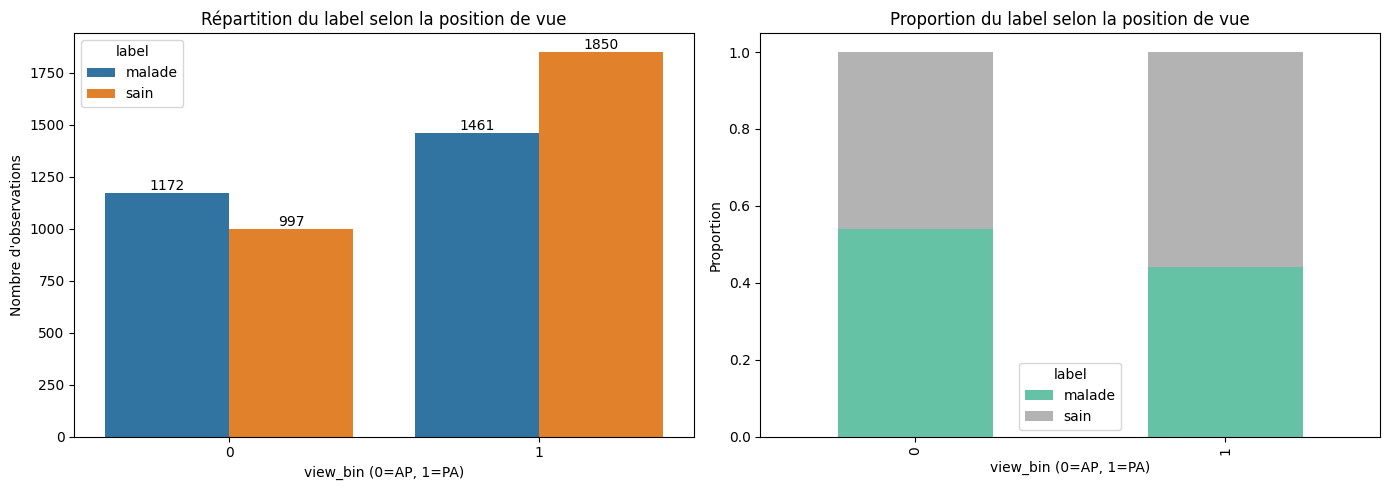

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot groupé
sns.countplot(data=df, x="view_bin", hue="label", ax=axes[0])
axes[0].set_title("Répartition du label selon la position de vue")
axes[0].set_xlabel("view_bin (0=AP, 1=PA)")
axes[0].set_ylabel("Nombre d'observations")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d")

# Barplot empilé normalisé
ct_label_view_norm.T.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Proportion du label selon la position de vue")
axes[1].set_xlabel("view_bin (0=AP, 1=PA)")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="label")

plt.tight_layout()
plt.show()

On observe une proportion plus élevée de patients malades parmi les clichés en position AP, car cette position est généralement utilisée lorsque le patient ne peut pas se tenir debout (urgences, soins intensifs). Cela constitue un biais lié au protocole d'acquisition qui pourrait influencer l'apprentissage du modèle.

#### 3. Croisement `label` × `age_group`

Observons maintenant comment la proportion de patients malades varie selon la tranche d'âge. Cette analyse permet de vérifier si certaines classes d'âge sont systématiquement plus associées à un diagnostic positif.

In [32]:
# Table de contingence label × age_group
ct_label_age = pd.crosstab(df["label"], df["age_group"], margins=True)
ct_label_age

age_group,"(0.999, 18.0]","(18.0, 30.0]","(30.0, 45.0]","(45.0, 60.0]","(60.0, 75.0]","(75.0, 120.0]",All
label,,,,,,,
malade,89,390,660,835,574,85,2633
sain,157,463,763,880,527,57,2847
All,246,853,1423,1715,1101,142,5480


In [33]:
# Proportions par tranche d'âge (profils colonnes)
ct_label_age_norm = pd.crosstab(df["label"], df["age_group"], normalize="columns")
ct_label_age_norm

age_group,"(0.999, 18.0]","(18.0, 30.0]","(30.0, 45.0]","(45.0, 60.0]","(60.0, 75.0]","(75.0, 120.0]"
label,,,,,,
malade,0.361789,0.45721,0.463809,0.48688,0.521344,0.598592
sain,0.638211,0.54279,0.536191,0.51312,0.478656,0.401408


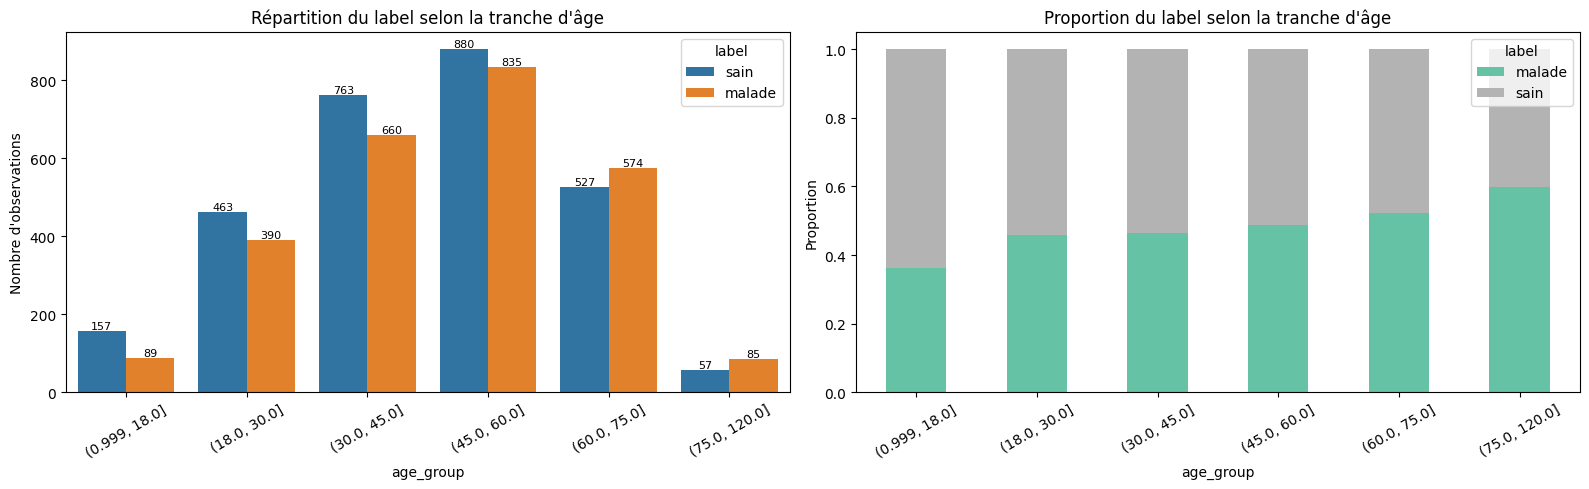

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot groupé
sns.countplot(data=df, x="age_group", hue="label", ax=axes[0])
axes[0].set_title("Répartition du label selon la tranche d'âge")
axes[0].set_xlabel("age_group")
axes[0].set_ylabel("Nombre d'observations")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", fontsize=8)
axes[0].tick_params(axis="x", rotation=30)

# Barplot empilé normalisé
ct_label_age_norm.T.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Proportion du label selon la tranche d'âge")
axes[1].set_xlabel("age_group")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="label")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

La proportion de malades croît avec l'âge, cela reflète un lien naturel entre le vieillissement et la prévalence des pathologies thoraciques. Toutefois, ce déséquilibre peut conduire le modèle à sur-diagnostiquer les patients âgés et sous-diagnostiquer les patients jeunes, ce qui constitue un biais lié à l'âge.

#### 4. Croisement `gender_bin` × `view_bin`

Étudions maintenant s'il existe une association entre le genre du patient et la position de prise de vue. Une telle association pourrait constituer un facteur de confusion dans l'analyse des biais.

In [35]:
# Table de contingence gender_bin × view_bin
ct_gender_view = pd.crosstab(df["gender_bin"], df["view_bin"], margins=True)
ct_gender_view

view_bin,0,1,All
gender_bin,,,
0,910,1539,2449
1,1259,1772,3031
All,2169,3311,5480


In [36]:
# Proportions par genre (profils lignes)
ct_gender_view_norm = pd.crosstab(df["gender_bin"], df["view_bin"], normalize="index")
ct_gender_view_norm

view_bin,0,1
gender_bin,,
0,0.371580,0.628420
1,0.415374,0.584626


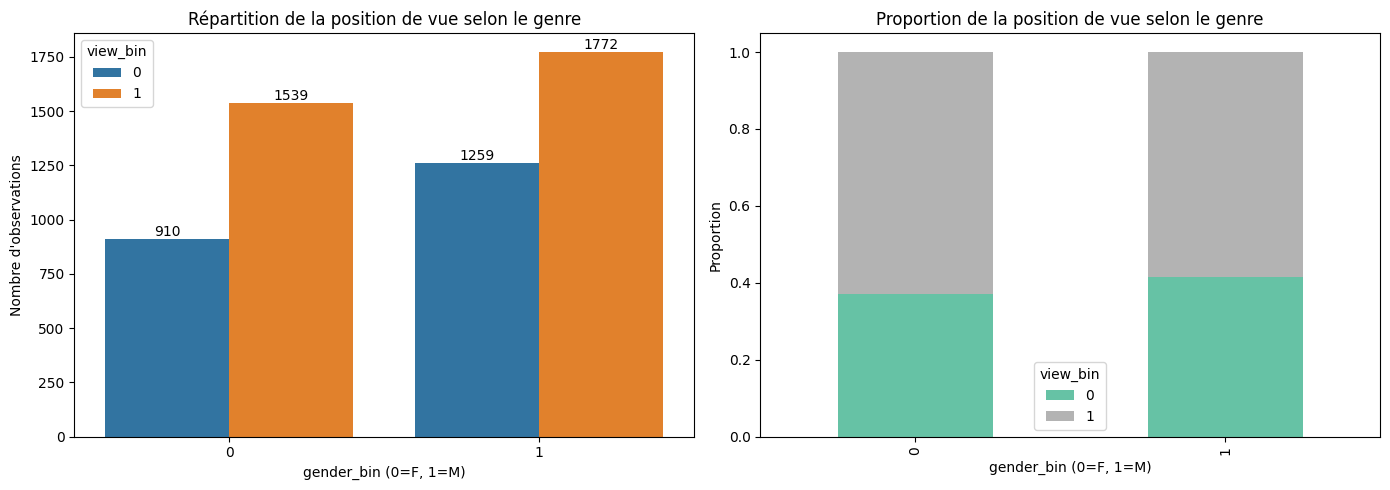

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot groupé
sns.countplot(data=df, x="gender_bin", hue="view_bin", ax=axes[0])
axes[0].set_title("Répartition de la position de vue selon le genre")
axes[0].set_xlabel("gender_bin (0=F, 1=M)")
axes[0].set_ylabel("Nombre d'observations")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d")

# Barplot empilé normalisé
ct_gender_view_norm.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Proportion de la position de vue selon le genre")
axes[1].set_xlabel("gender_bin (0=F, 1=M)")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="view_bin")

plt.tight_layout()
plt.show()

On note une distribution inégale des effectifs entre les sous-groupes genre et position de vue , cela pourrait introduire un biais de prédiction.

#### 5. Croisement `gender_bin` × `age_group`

Vérifions si la distribution des tranches d'âge diffère entre les hommes et les femmes. Un déséquilibre marqué pourrait signifier que certains sous-groupes (par exemple, les femmes âgées) sont sous-représentés.

In [38]:
# Table de contingence gender_bin × age_group
ct_gender_age = pd.crosstab(df["gender_bin"], df["age_group"], margins=True)
ct_gender_age

age_group,"(0.999, 18.0]","(18.0, 30.0]","(30.0, 45.0]","(45.0, 60.0]","(60.0, 75.0]","(75.0, 120.0]",All
gender_bin,,,,,,,
0,78,372,653,849,464,33,2449
1,168,481,770,866,637,109,3031
All,246,853,1423,1715,1101,142,5480


In [39]:
# Proportions par genre (profils lignes)
ct_gender_age_norm = pd.crosstab(df["gender_bin"], df["age_group"], normalize="index")
ct_gender_age_norm

age_group,"(0.999, 18.0]","(18.0, 30.0]","(30.0, 45.0]","(45.0, 60.0]","(60.0, 75.0]","(75.0, 120.0]"
gender_bin,,,,,,
0,0.031850,0.151899,0.266639,0.346672,0.189465,0.013475
1,0.055427,0.158694,0.254042,0.285714,0.210162,0.035962


On trace le graphe :

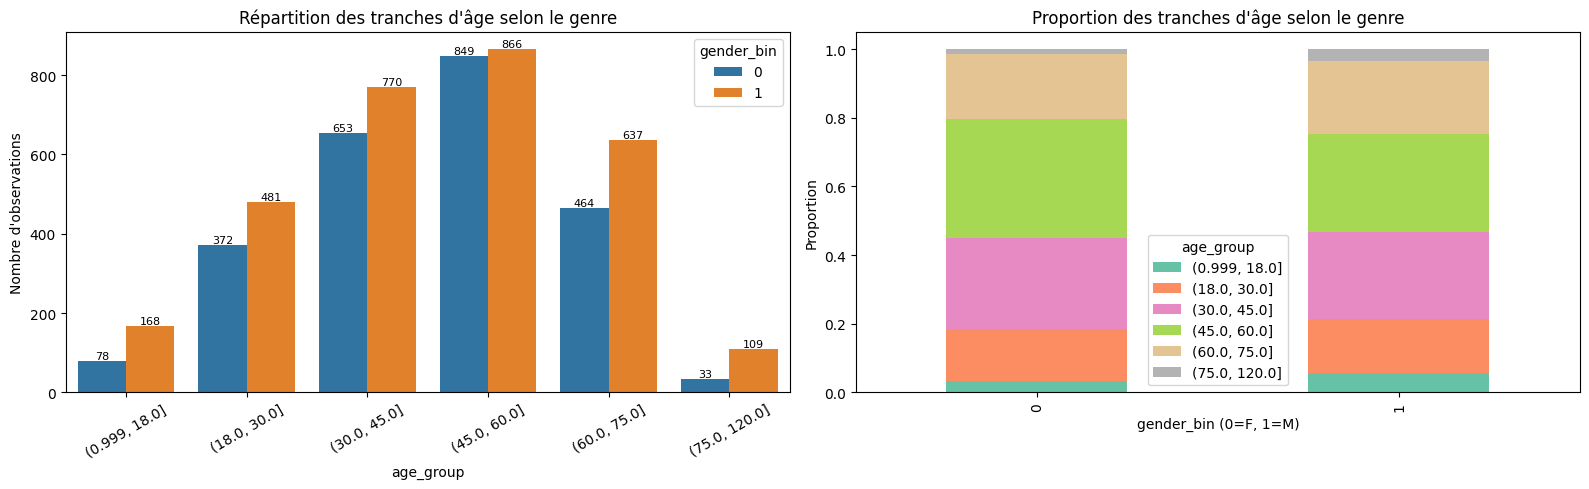

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot groupé
sns.countplot(data=df, x="age_group", hue="gender_bin", ax=axes[0])
axes[0].set_title("Répartition des tranches d'âge selon le genre")
axes[0].set_xlabel("age_group")
axes[0].set_ylabel("Nombre d'observations")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", fontsize=8)
axes[0].tick_params(axis="x", rotation=30)

# Barplot empilé normalisé
ct_gender_age_norm.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Proportion des tranches d'âge selon le genre")
axes[1].set_xlabel("gender_bin (0=F, 1=M)")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="age_group")

plt.tight_layout()
plt.show()

Le croisement entre `gender_bin` et `age_group` nous permet d’examiner si la structure d’âge est comparable entre les deux genres. Le graphique en effectifs montre que les hommes (valeur 1) sont globalement plus nombreux que les femmes (valeur 0) dans presque toutes les tranches d’âge, ce qui est cohérent avec le léger déséquilibre déjà observé lors de l’analyse univariée de `gender_bin`.

Le graphique en proportions est toutefois plus informatif : il montre que les profils d’âge des deux groupes restent relativement proches. Les principales tranches d’âge sont représentées dans des proportions comparables chez les femmes et chez les hommes, même si l’on observe une légère surreprésentation des hommes dans les classes d’âge les plus élevées.
Ainsi, cette analyse ne met pas en évidence un biais majeur entre l'âge et le genre. Il existe bien quelques écarts, mais ils restent modérés et ne suggèrent pas, une sous-représentation très marquée d’un sous-groupe particulier.


#### 6. Croisement `view_bin` × `age_group`

Enfin, étudions si la position de prise de vue varie selon la tranche d'âge. Les patients les plus âgés ou les plus jeunes pourraient être davantage photographiés en position AP (patients alités), ce qui créerait un biais croisé entre l'âge et le mode d'acquisition.

In [41]:
# Table de contingence view_bin × age_group
ct_view_age = pd.crosstab(df["view_bin"], df["age_group"], margins=True)
ct_view_age

age_group,"(0.999, 18.0]","(18.0, 30.0]","(30.0, 45.0]","(45.0, 60.0]","(60.0, 75.0]","(75.0, 120.0]",All
view_bin,,,,,,,
0,116,403,586,634,392,38,2169
1,130,450,837,1081,709,104,3311
All,246,853,1423,1715,1101,142,5480


In [42]:
# Proportions par tranche d'âge (profils colonnes)
ct_view_age_norm = pd.crosstab(df["view_bin"], df["age_group"], normalize="columns")
ct_view_age_norm

age_group,"(0.999, 18.0]","(18.0, 30.0]","(30.0, 45.0]","(45.0, 60.0]","(60.0, 75.0]","(75.0, 120.0]"
view_bin,,,,,,
0,0.471545,0.47245,0.411806,0.369679,0.35604,0.267606
1,0.528455,0.52755,0.588194,0.630321,0.64396,0.732394


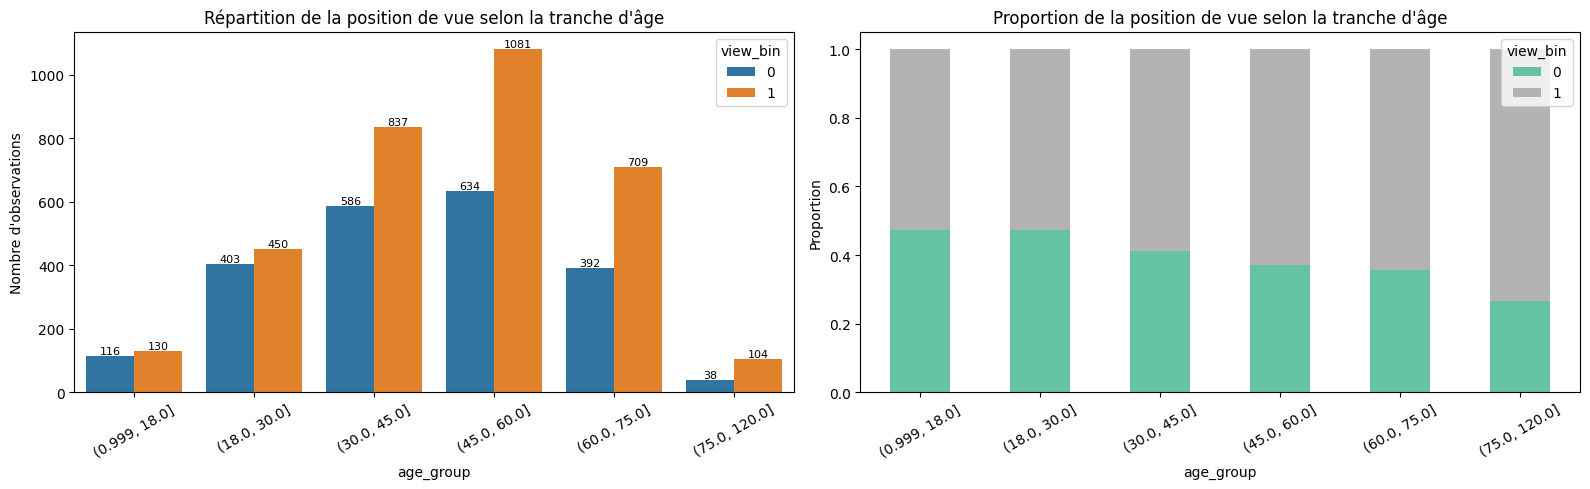

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot groupé
sns.countplot(data=df, x="age_group", hue="view_bin", ax=axes[0])
axes[0].set_title("Répartition de la position de vue selon la tranche d'âge")
axes[0].set_xlabel("age_group")
axes[0].set_ylabel("Nombre d'observations")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", fontsize=8)
axes[0].tick_params(axis="x", rotation=30)

# Barplot empilé normalisé
ct_view_age_norm.T.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Proportion de la position de vue selon la tranche d'âge")
axes[1].set_xlabel("age_group")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="view_bin")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Le croisement entre `view_bin` et `age_group` nous permet d’examiner si la position de prise de vue dépend de l’âge des patients. 
En effet, le graphique en effectifs montre que `view_bin = 1` est majoritaire dans toutes les tranches d’âge, ce qui est cohérent avec l’analyse univariée où cette position de vue était déjà surreprésentée.
Le graphique en proportions met toutefois en évidence un phénomène plus structuré : la part de `view_bin = 0` est plus élevée chez les patients les plus jeunes, puis diminue progressivement avec l’âge, tandis que la part de `view_bin = 1` augmente.

Autrement dit, la distribution de la position de prise de vue n’est pas identique selon les tranches d’âge.

Cette analyse suggère donc l’existence d’un déséquilibre entre l’âge et le mode d’acquisition. Ce biais n’est pas extrême, mais il est suffisamment visible pour être pris en compte dans la suite, car le modèle pourrait en partie exploiter des différences liées à la position de vue qui sont elles-mêmes corrélées à l’âge.


#### 7. Matrice de corrélation entre les variables numériques

Pour avoir une vue d'ensemble des corrélations entre les différentes variables numériques et binaires, nous calculons et affichons une matrice de corrélation. Cela permet de résumer rapidement les associations linéaires entre les variables.

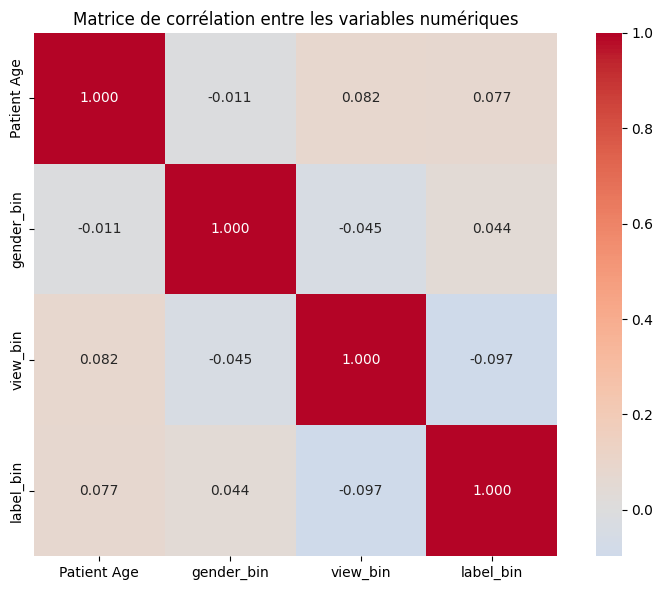

In [44]:
# Sélection des variables numériques/binaires pertinentes
cols_corr = ["Patient Age", "gender_bin", "view_bin", "label_bin"]
corr_matrix = df[cols_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", center=0, square=True)
plt.title("Matrice de corrélation entre les variables numériques")
plt.tight_layout()
plt.show()

La matrice de corrélation nous montre que les associations linéaires entre les variables numériques et binaires du jeu de données restent globalement faibles. Aucune corrélation forte n’apparaît entre l’âge, le genre, la position de vue et la variable cible. Ainsi, cela suggère qu’aucune de ces variables, prise isolément, n’explique fortement l’état de santé du patient dans une relation linéaire simple.

On observe néanmoins quelques tendances faibles. La corrélation entre `view_bin` et `label_bin` est légèrement négative, ce qui indique que la proportion de patients malades varie un peu selon la position de prise de vue. De même, `Patient Age` présente une très légère corrélation positive avec `label_bin`, suggérant que l’état de santé pourrait être un peu plus fréquent dans certaines tranches d’âge. En revanche, `gender_bin` semble très faiblement corrélé aux autres variables.

Cette matrice nous confirme donc l’absence de dépendances linéaires marquées, tout en mettant en évidence quelques relations modestes que l'on a déjà aperçues dans l’analyse bivariée, notamment entre l’âge, la position de vue et la variable cible.


### Synthèse de l'analyse bivariée

L’analyse bivariée nous a confirmé que le jeu de données présente plusieurs déséquilibres. Les différences les plus visibles concernent la répartition du `label` selon `age_group` et selon `view_bin`, ce qui suggère que l’âge et la position de prise de vue sont liés à l’état de santé. 

Par ailleurs, les croisements entre variables sensibles montrent néanmoins des écarts plus modérés, notamment entre `gender_bin` et `view_bin`, ainsi qu’entre `gender_bin` et `age_group`. Enfin, le lien entre `view_bin` et `age_group` apparaît plus marqué, ce qui révèle un biais potentiel entre l’âge et le mode d’acquisition des images. 

Dans l’ensemble, ces résultats montrent que certaines variables sensibles ne sont pas réparties indépendamment les unes des autres, ce qui pourrait influencer les prédictions du classifieur.


## III. Entraînement du modèle pour obtenir des valeurs de référence

Après l’analyse exploratoire du jeu de données, commençons par entraîner un modèle de référence sans appliquer aucun traitement sur les données. Tous les poids étant initialement fixés à 1, ce premier entraînement nous permettra d'obtenir une baseline de performance et d’équité, qui servira ensuite de point de comparaison pour évaluer l’effet des méthodes de pre-processing puis de post-processing.

In [45]:
from train_classifieur import train_classifier, pred_classifier
from datetime import datetime

In [46]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [47]:
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

NVIDIA GeForce RTX 5060 Laptop GPU
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


On souhaite entraîner le classifieur sur notre jeu de données que l'on vient de nettoyer. Ainsi, l'on transforme notre dataframe nettoyé en un fichier CSV.

In [48]:
df_clean = df.copy()
df_clean.to_csv("./DATA/metadata_clean.csv", index=False)

In [ ]:
%%time
# This cell show how to train a model
#
# You are going to train several time the models, with different weights
#
# The experiment folder name (logdir) suggested contains the timestamp
# you can change this to add some description in the name
# or add a file in the logdir folder to describe your intention and parameters
# Warning: For Colab users, the logdir needs to be on your drive (as in this example)
# It will allow you to keep your trained models, even if you get disconnected
#
# By default, to help you reproduce you experiments the csv file
# used for the training is copied in the logdir folder.

# This can take around 20-30min to run on PUIO computer
# And around 10 min on Colab with a GPU
dt = datetime.now()
timeStamp = dt.strftime('%Y_%m_%d_%H_%M_%S')
logdir = f"./expe_log/{timeStamp}"
ckpt_path_baseline, ckpt_score = train_classifier(
    logdir=logdir,
    datadir=f"./DATA/",
    csv=f"./DATA/metadata_clean.csv", # on utilise notre fichier CSV contenant le dataset nettoyé et les variables binaires.
    weights_col="WEIGHTS")

On génère les prédictions :

In [ ]:
%%time
# This cell show how to perform predictions with a train model
# the ckpt_path outputed in the previous cell refer to the best model obtained
# during the training, you can replace this by any .ckpt file obtained
pred_classifier(
    datadir=f"./DATA/",
    csv_in=f"./DATA/metadata_clean.csv",
    csv_out=f"{logdir}/preds_baseline.csv",
    ckpt_path = ckpt_path_baseline
)

## IV. Analyse des métriques de fairness et application des méthodes de pre-processing

### 1. Analyse des métriques de fairness

Dans cette partie, nous utiliserons la fonction vue en cours `get_metrics` dont voici son implémentation :

In [49]:
# This method takes lists
def get_metrics(
    y_true, # list or np.array of truth values
    y_pred=None,  # list or np.array of predictions
    prot_attr=None, # list or np.array of protected/sensitive attribute values
    priv_group=1, # value taken by the privileged group
    pos_label=1, # value taken by the positive truth/prediction
    sample_weight=None # list or np.array of weights value,
):
    group_metrics = {}
    group_metrics["base_rate_truth"] = base_rate(
        y_true=y_true, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["statistical_parity_difference"] = statistical_parity_difference(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["disparate_impact_ratio"] = disparate_impact_ratio(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    if not y_pred is None:
        group_metrics["base_rate_preds"] = base_rate(
        y_true=y_pred, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["equal_opportunity_difference"] = equal_opportunity_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["average_odds_difference"] = average_odds_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        if len(set(y_pred))>1:
            group_metrics["conditional_demographic_disparity"] = conditional_demographic_disparity(
                y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
            )
        else:
            group_metrics["conditional_demographic_disparity"] =None
        group_metrics["smoothed_edf"] = smoothed_edf(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["df_bias_amplification"] = df_bias_amplification(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["balanced_accuracy_score"] = balanced_accuracy_score(
        y_true=y_true, y_pred=y_pred, sample_weight=sample_weight
        )
    return group_metrics

Commençons par analyser les métriques de fairness directement sur le jeu de données sans se soucier du classifieur. Ceci va nous permettre d’évaluer les déséquilibres initiaux entre groupes sensibles à partir de la variable cible.

#### Mesurons les métriques de fairness du jeu de données selon la variable sensible `gender_bin`

In [50]:
metrics_gender_data = get_metrics(
    y_true=df["label_bin"].to_numpy(),
    y_pred=None,
    prot_attr=df["gender_bin"].to_numpy(),
    priv_group=1,
    pos_label=1
)

# Conversion du dictionnaire de métriques en DataFrame
# pour un meilleur affichage
metrics_gender_data_df = pd.DataFrame.from_dict(
    metrics_gender_data, orient="index", columns=["gender_bin"]
)

metrics_gender_data_df

,gender_bin
base_rate_truth,0.480474
statistical_parity_difference,-0.044060
disparate_impact_ratio,0.911908


Les métriques calculées selon `gender_bin` montrent que le jeu de données présente un léger déséquilibre entre les deux groupes. Le `base_rate_truth` vaut environ 0,48, ce qui signifie qu’en moyenne, près de 48 % des individus sont étiquetés comme malades dans l’ensemble des données.

La `statistical_parity_difference` est légèrement négative (-0,044), ce qui indique que le groupe non privilégié présente une proportion de cas positifs un peu plus faible que le groupe privilégié. De même, le `disparate_impact_ratio` vaut environ 0,91, soit une valeur inférieure à 1, ce qui confirme un écart modéré entre les deux groupes.


#### Mesurons les métriques de fairness du jeu de données selon la variable sensible `view_bin`

Nous répétons ensuite la même analyse pour la variable sensible `view_bin`, afin d’évaluer un éventuel déséquilibre lié à la position de prise de vue.

In [51]:
metrics_view_data = get_metrics(
    y_true=df["label_bin"].to_numpy(),
    y_pred=None,
    prot_attr=df["view_bin"].to_numpy(),
    priv_group=1,
    pos_label=1
)

# Conversion du dictionnaire de métriques en DataFrame
# pour un meilleur affichage
metrics_view_data_df = pd.DataFrame.from_dict(
    metrics_view_data, orient="index", columns=["view_bin"]
)

metrics_view_data_df

,view_bin
base_rate_truth,0.480474
statistical_parity_difference,0.099085
disparate_impact_ratio,1.224551


Les métriques de fairness calculées selon `view_bin` mettent en évidence un déséquilibre plus visible dans le jeu de données. Le `base_rate_truth` reste identique, avec environ 48 % de cas positifs dans l’ensemble des données.

La `statistical_parity_difference` est ici positive et vaut environ 0,099, ce qui indique que la proportion de patients malades est plus élevée dans le groupe non privilégié que dans le groupe privilégié. Le `disparate_impact_ratio` vaut environ 1,225, ce qui s’éloigne davantage de la valeur idéale 1 que dans le cas de `gender_bin`.

On en déduit que la variable `view_bin` semble davantage liée à la distribution du label que `gender_bin`.

**Remarque** : nous n'avons pas calculé les métriques de fairness du niveau de suivi, puisque dans le projet, on s'intéresse plutôt aux attributs particulièrement sensibles (comme `Patient Gender` ou `View Position`) que le modèle peut retrouver directement à partir des images.

#### On affiche un petit tableau récapitulatif :

In [52]:
fairness_data = pd.concat([metrics_gender_data_df, metrics_view_data_df], axis=1)
fairness_data

,gender_bin,view_bin
base_rate_truth,0.480474,0.480474
statistical_parity_difference,-0.044060,0.099085
disparate_impact_ratio,0.911908,1.224551


### 2. Application des méthodes de pré-processing

Après avoir entraîné le modèle pour obtenir des valeurs de référence et analysé les déséquilibres initiaux du jeu de données, nous allons désormais appliquer des méthodes de pré-processing. Dans le cadre de ce projet, ces méthodes consistent à modifier les poids des observations dans la colonne WEIGHTS, afin d’étudier l’effet de différentes stratégies de pondération sur les performances du classifieur et sur les métriques de fairness.

#### 1. Première stratégie de pondération : Reweighting sur `view_bin`

Nous appliquons d’abord une première stratégie de pré-processing fondée sur le reweighting. L’idée est d’ajuster les poids des observations en fonction de `view_bin` et du label, afin de réduire les déséquilibres initiaux entre groupes avant l’entraînement du classifieur.

In [53]:
def compute_reweighing_weights(df, prot_attr, target_col="label_bin"):
    """
    Calcule des poids de reweighting pour chaque observation.

    Idée :
    on compare la probabilité attendue sous indépendance
    P(groupe) * P(classe)
    à la probabilité réellement observée
    P(groupe, classe).

    Le poids attribué à une ligne est donc :
    poids = [P(groupe) * P(classe)] / P(groupe, classe)
    """

    # Copie des deux colonnes utiles : attribut protégé et cible
    df_temp = df[[prot_attr, target_col]].copy()

    # Probabilités marginales P(groupe)
    prob_group = df_temp[prot_attr].value_counts(normalize=True)

    # Probabilités marginales P(classe)
    prob_class = df_temp[target_col].value_counts(normalize=True)

    # Probabilités conjointes observées P(groupe, classe)
    prob_joint = df_temp.groupby([prot_attr, target_col]).size() / len(df_temp)

    # Fonction qui calcule le poids d'une ligne
    def get_weight(row):
        g = row[prot_attr]
        c = row[target_col]

        # Probabilité attendue si groupe et classe étaient indépendants
        expected = prob_group[g] * prob_class[c]

        # Probabilité réellement observée
        observed = prob_joint.loc[g, c]

        return expected / observed

    # Calcul du poids pour chaque ligne
    return df_temp.apply(get_weight, axis=1)

On calcule désormais les poids de reweighting associés à `view_bin`, puis on les stocke dans la colonne `WEIGHTS`.

In [54]:
# Calcul des nouveaux poids selon la variable sensible view_bin
weights_view = compute_reweighing_weights(df, prot_attr="view_bin", target_col="label_bin")

# On crée une copie du dataframe
df_rw_view = df.copy()

# On remplace la colonne WEIGHTS par les poids calculés
df_rw_view["WEIGHTS"] = weights_view

On vérifie rapidement :

In [55]:
df_rw_view[["view_bin", "label_bin", "WEIGHTS"]].head()

,view_bin,label_bin,WEIGHTS
0,1,0,0.929810
1,0,1,0.889206
2,0,1,0.889206
3,0,1,0.889206
4,0,1,0.889206


On compare désormais les métriques de fairness obtenues avant Reweighting et après Reweighting.
On crée pour cela une fonction afin de gagner du temps pour la suite :

In [56]:
def compare_bias_reduction(y_true, prot_attr, w_before=None, w_after=None,
                           label_before="Original", label_after="Reweighted"):
    """
    Permet de comparer les métriques de fairness avant et après pondération.
    """
    metrics_before = get_metrics(
        y_true=y_true,
        y_pred=None,
        prot_attr=prot_attr,
        priv_group=1,
        pos_label=1,
        sample_weight=w_before
    )

    metrics_after = get_metrics(
        y_true=y_true,
        y_pred=None,
        prot_attr=prot_attr,
        priv_group=1,
        pos_label=1,
        sample_weight=w_after
    )

    comparison_df = pd.DataFrame({
        label_before: metrics_before,
        label_after: metrics_after
    })

    # On garde uniquement les métriques pertinentes
    return comparison_df.loc[
        ["statistical_parity_difference", "disparate_impact_ratio", "base_rate_truth"]
    ]

On exécute la fonction :

In [57]:
# Comparaison avant / après reweighting sur view_bin
res_view_rw = compare_bias_reduction(
    y_true=df["label_bin"].values,
    prot_attr=df["view_bin"].values,
    w_before=None,
    w_after=df_rw_view["WEIGHTS"].values,
    label_before="Avant reweighting",
    label_after="Après reweighting"
)

res_view_rw

,Avant reweighting,Après reweighting
statistical_parity_difference,0.099085,0.000000
disparate_impact_ratio,1.224551,1.000000
base_rate_truth,0.480474,0.480474


Comme on pouvait s'y attendre, les résultats obtenus après reweighting sont ici idéaux au niveau des données pondérées : la `statistical_parity_difference` devient nulle et le `disparate_impact_ratio` vaut exactement 1, tandis que le `base_rate_truth` reste inchangé. Ce comportement était attendu, puisque la pondération a été construite précisément pour rééquilibrer la distribution conjointe entre `view_bin` et `label_bin`. En revanche, cela ne garantit pas que les prédictions du modèle entraîné sur ces données seront elles aussi parfaitement fair. On ne pourra répondre qu'à cette question qu'après un nouvel entraînement du modèle.

On crée un nouveau fichier CSV avec les poids modifiés afin de pouvoir entraîner le classifieur :

In [58]:
df_rw_view.to_csv("./DATA/metadata_rw_view_bin.csv", index=False)

#### 2. Deuxième stratégie de pondération : Reweighting sur `gender_bin`

Nous appliquons la même logique de reweighting pour la variable sensible `gender_bin`.

In [61]:
# Calcul des nouveaux poids selon la variable sensible gender_bin
weights_gender = compute_reweighing_weights(df, prot_attr="gender_bin", target_col="label_bin")

df_rw_gender = df.copy()
df_rw_gender["WEIGHTS"] = weights_gender

# Validation
res_gender_rw = compare_bias_reduction(
    y_true=df["label_bin"].values,
    prot_attr=df["gender_bin"].values,
    w_before=None,
    w_after=df_rw_gender["WEIGHTS"].values,
    label_before="Avant reweighting",
    label_after="Après reweighting"
)

# Sauvegarde
df_rw_gender.to_csv("./DATA/metadata_rw_gender_bin.csv", index=False)

res_gender_rw

,Avant reweighting,Après reweighting
statistical_parity_difference,-0.044060,-5.551115e-17
disparate_impact_ratio,0.911908,1.000000e+00
base_rate_truth,0.480474,4.804745e-01


#### 3. Troisième stratégie de pondération : Reweighting sur `age_group`

Nous appliquons enfin la même logique de reweighting pour la variable sensible `age_group`, qui comporte plusieurs catégories.

In [60]:
# Calcul des nouveaux poids selon la variable sensible age_group
weights_age = compute_reweighing_weights(df, prot_attr="age_group", target_col="label_bin")

df_rw_age = df.copy()
df_rw_age["WEIGHTS"] = weights_age

# Validation
# Note : Pour age_group (multiclasse), statistical_parity_difference compare par défaut le groupe privilégié (souvent arbitraire ou le majoritaire) aux autres.
# Ici, la fonction get_metrics attend une valeur binaire ou spécifique pour le groupe privilégié.
# Pour simplifier l'affichage de validation ici, on vérifie juste que la distribution est équilibrée globalement.
# Cependant, notre fonction compare_bias_reduction est conçue pour du binaire. On l'adapte ou on observe juste les poids.

print("Poids moyens par groupe d'âge :")
print(df_rw_age.groupby(["age_group", "label_bin"])["WEIGHTS"].mean())

# Sauvegarde
df_rw_age.to_csv("./DATA/metadata_rw_age_group.csv", index=False)

/tmp/ipykernel_3270/1968422401.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_joint = df_temp.groupby([prot_attr, target_col]).size() / len(df_temp)


Poids moyens par groupe d'âge :
age_group      label_bin
(0.999, 18.0]  0            0.814034
               1            1.328053
(18.0, 30.0]   0            0.957139
               1            1.050884
(30.0, 45.0]   0            0.968919
               1            1.035932
(45.0, 60.0]   0            1.012484
               1            0.986843
(60.0, 75.0]   0            1.085384
               1            0.921607
(75.0, 120.0]  0            1.294257
               1            0.802675
Name: WEIGHTS, dtype: float64


/tmp/ipykernel_3270/4023049017.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_rw_age.groupby(["age_group", "label_bin"])["WEIGHTS"].mean())


#### 4. Quatrième stratégie : Resampling (Ré-échantillonnage)

Le resampling consiste à modifier la distribution des données d'entraînement non pas en attribuant des poids (qui modifient la loss function), mais en échantillonnant les observations avec remise. Les observations sous-représentées (ou celles ayant un poids élevé) seront dupliquées, tandis que celles sur-représentées (poids faible) seront moins fréquentes.
Nous allons créer un dataset ré-échantillonné basé sur les poids calculés pour `view_bin` (car c'était la variable présentant le plus de biais).

In [ ]:
def resample_dataset(df, weights_col="WEIGHTS", n_samples=None):
    """
    Effectue un tirage avec remise pondéré par la colonne weights_col.
    """
    if n_samples is None:
        n_samples = len(df)
    
    # Echantillonnage pondéré
    df_resampled = df.sample(
        n=n_samples,
        replace=True,
        weights=weights_col, # Les poids déterminent la probabilité d'être tiré
        random_state=42
    )
    
    # Une fois rééchantillonné, les poids individuels redeviennent 1
    # car le déséquilibre est compensé par la duplication/omission de lignes.
    df_resampled[weights_col] = 1.0
    
    return df_resampled

# Application du resampling basé sur les poids de view_bin
df_resampled_view = resample_dataset(df_rw_view, weights_col="WEIGHTS")

# Sauvegarde
df_resampled_view.to_csv("./DATA/metadata_resampled_view.csv", index=False)

print(f"Taille du dataset original : {len(df)}")
print(f"Taille du dataset resamplé : {len(df_resampled_view)}")

# Vérification que la distribution s'est équilibrée (stat parity diff proche de 0)
metrics_resampled = get_metrics(
    y_true=df_resampled_view["label_bin"].to_numpy(),
    prot_attr=df_resampled_view["view_bin"].to_numpy(),
    priv_group=1,
    pos_label=1
)
pd.DataFrame.from_dict(metrics_resampled, orient="index", columns=["Resampled View Data"])

### 3. Entraînement centralisé des modèles

Nous allons maintenant entraîner un classifieur pour chacune des stratégies définies ci-dessus (Reweighting View, Reweighting Gender, Reweighting Age, Resampling View) via une boucle automatisée.

In [ ]:
from datetime import datetime
from train_classifieur import train_classifier, pred_classifier
import torch

In [1]:
experiments = [
    {
        "name": "Reweighting View",
        "csv": "./DATA/metadata_rw_view_bin.csv",
        "weights_col": "WEIGHTS"
    },
    {
        "name": "Reweighting Gender",
        "csv": "./DATA/metadata_rw_gender_bin.csv",
        "weights_col": "WEIGHTS"
    },
    {
        "name": "Reweighting Age",
        "csv": "./DATA/metadata_rw_age_group.csv",
        "weights_col": "WEIGHTS"
    },
    {
        "name": "Resampling View",
        "csv": "./DATA/metadata_resampled_view.csv",
        "weights_col": "WEIGHTS"
    }
]

experiment_results = {}

dt = datetime.now()
timeStamp = dt.strftime('%Y_%m_%d_%H_%M_%S')
base_logdir = f"./expe_log/{timeStamp}"

print(f"Début de la campagne d'entraînement. Logs dans : {base_logdir}")

for exp in experiments:
    exp_name = exp["name"]
    print(f"\n=== Entraînement : {exp_name} ===")
    
    # Dossier spécifique pour ce run
    # On remplace les espaces par des underscores pour le dossier
    safe_name = exp_name.replace(" ", "_")
    logdir = f"{base_logdir}/{safe_name}"
    
    # Entraînement
    ckpt_path, ckpt_score = train_classifier(
        logdir=logdir,
        datadir="./DATA/",
        csv=exp["csv"],
        weights_col=exp["weights_col"]
    )
    
    # Prédiction
    pred_csv_out = f"{logdir}/preds_{safe_name}.csv"
    pred_classifier(
        datadir="./DATA/",
        csv_in=exp["csv"],
        csv_out=pred_csv_out,
        ckpt_path=ckpt_path
    )
    
    experiment_results[exp_name] = {
        "ckpt_path": ckpt_path,
        "score": ckpt_score,
        "preds_csv": pred_csv_out
    }
    
print("\nCampagne terminée !")

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x734588f78760>>
Traceback (most recent call last):
  File "/home/zenaidi/.local/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


NameError: name 'datetime' is not defined

In [ ]:
experiment_results